In [78]:
import pandas as pd
df = pd.read_csv('data/train_cleaned_and_engineered.csv')
df.head()

,Survived,Pclass,Sex,Age,Fare,Age_null,has_cabin,fam_size_medium,fam_size_large,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,0.2750,2.110213,0,0,1,0,0,1,0,1,0,0
1,1,1,1,0.4750,4.280593,0,1,1,0,0,0,0,0,1,0
2,1,3,1,0.3250,2.188856,0,0,0,0,0,1,1,0,0,0
3,1,1,1,0.4375,3.990834,0,1,1,0,0,1,0,0,1,0
4,0,3,0,0.4375,2.202765,0,0,0,0,0,1,0,1,0,0


# Naiva Bayes Classifier

Our baseline model. Our benchmark for our Linear Regression Model.

We will be making a Mixed Naive Bayes Classifier, since we have both continuous and discrete features.

# Mixed NB

In [79]:
import numpy as np
from scipy.special import logsumexp
from sklearn.naive_bayes import BernoulliNB, GaussianNB


class MixedNB:
    def __init__(self, binary_features, continuous_features, alpha=1.0):
        self.bnb = BernoulliNB(alpha=alpha)
        self.gnb = GaussianNB()
        self.binary_features = binary_features
        self.continuous_features = continuous_features

    def fit(self, X, y):
        self.bnb.fit(X[:, self.binary_features], y)
        self.gnb.fit(X[:, self.continuous_features], y)
        self.classes_ = self.bnb.classes_
        return self

    def predict_probs(self, X):
        # Add log probs, subtract one prior (counted twice)
        log_prior = self.bnb.class_log_prior_
        log_prob = (
            self.bnb.predict_log_proba(X[:, self.binary_features]) +
            self.gnb.predict_log_proba(X[:, self.continuous_features]) -
            log_prior
        )
        # Normalize
        log_prob -= logsumexp(log_prob, axis=1, keepdims=True)
        return np.exp(log_prob)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_probs(X), axis=1)]

## Bernoulli NB
This is for handling binary features:

- Sex

- Age_null

- Cabin_null

- Embarked_null

- has_cabin

- fam_size_medium

- fam_size_large

- Embarked_Q

- Embarked_S

- Title_Miss

- Title_Mlle

- Title_Mme

- Title_Mr

- Title_Mrs

- Title_Rare

- Pclass_1

- Pclass_2

- Pclass_3

### Minor Issue: PClass's Ordinal Approach is incompatible with NB.
Solution: Create OHE for PClass for NB. Keep PClass Ordinal.

In [80]:
# OHE Pclass for Bernoulli NB (preserves ordinal column for logistic regression)
df = pd.get_dummies(df, columns=['Pclass'], prefix='Pclass', dtype=int)

print(df[[c for c in df.columns if c.startswith('Pclass')]].head())

   Pclass_1  Pclass_2  Pclass_3
0         0         0         1
1         1         0         0
2         0         0         1
3         1         0         0
4         0         0         1


## GaussianNB

For handling continuous features:

- Age

- Fare

In [81]:
binary_features = [
    'Sex', 'Age_null', 'has_cabin',
    'fam_size_medium', 'fam_size_large',
    'Embarked_Q', 'Embarked_S',
    'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare',
    'Pclass_1', 'Pclass_2', 'Pclass_3',
]
continuous_features = ['Age', 'Fare']

all_features = binary_features + continuous_features
X = df[all_features].values
y = df['Survived'].values

binary_idx = list(range(len(binary_features)))
continuous_idx = list(range(len(binary_features), len(all_features)))

for alpha in [1.0, 0.01]:
    mnb = MixedNB(binary_features=binary_idx, continuous_features=continuous_idx, alpha=alpha)
    mnb.fit(X, y)
    print(f"alpha={alpha:<4}  Training accuracy: {(mnb.predict(X) == y).mean():.4f}")

alpha=1.0   Training accuracy: 0.7818
alpha=0.01  Training accuracy: 0.7818


### Comment on Varying Alpha
We see no difference in accuracy between the two. This is likely explained by the fact that we don't have sparse data, since that's what Laplace smoothing solves for.

# Linear Regression

In [82]:
from sklearn.linear_model import LinearRegression

# Use ordinal Pclass (from original CSV) + all other features
lr_features = [
    'Sex', 'Age', 'Fare',
    'Age_null', 'has_cabin',
    'fam_size_medium', 'fam_size_large',
    'Embarked_Q', 'Embarked_S',
    'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare',
]

# Re-read ordinal Pclass since we OHE'd it earlier for NB
df_raw = pd.read_csv('data/train_cleaned_and_engineered.csv')
X_lr = df_raw[['Pclass'] + lr_features].values
y_lr = df_raw['Survived'].values

lr = LinearRegression()
lr.fit(X_lr, y_lr)

y_pred = (lr.predict(X_lr) >= 0.5).astype(int)
print(f"Training accuracy: {(y_pred == y_lr).mean():.4f}")

Training accuracy: 0.8324


# Regularization

## L1 (Lasso) Regularization

In [83]:
from sklearn.linear_model import Lasso

X_lasso = X_lr  # same features as OLS
y_lasso = y_lr

for alpha in [0.1, 1.0, 10, 100, 1000, 10000]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_lasso, y_lasso)
    y_pred_lasso = (lasso.predict(X_lasso) >= 0.5).astype(int)
    n_nonzero = (lasso.coef_ != 0).sum()
    print(f"alpha={alpha:<5}  accuracy={( y_pred_lasso == y_lasso).mean():.4f}  nonzero_coefs={n_nonzero}/{len(lasso.coef_)}")

alpha=0.1    accuracy=0.7064  nonzero_coefs=3/14
alpha=1.0    accuracy=0.6175  nonzero_coefs=0/14
alpha=10     accuracy=0.6175  nonzero_coefs=0/14
alpha=100    accuracy=0.6175  nonzero_coefs=0/14
alpha=1000   accuracy=0.6175  nonzero_coefs=0/14
alpha=10000  accuracy=0.6175  nonzero_coefs=0/14


## L2 (Ridge) Regularization

In [84]:
from sklearn.linear_model import Ridge

X_ridge = X_lr
y_ridge = y_lr

for alpha in [0.1, 1.0, 10, 100, 1000, 10000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_ridge, y_ridge)
    y_pred_ridge = (ridge.predict(X_ridge) >= 0.5).astype(int)
    print(f"alpha={alpha:<5}  accuracy={(y_pred_ridge == y_ridge).mean():.4f}")

alpha=0.1    accuracy=0.8324
alpha=1.0    accuracy=0.8335
alpha=10     accuracy=0.8369
alpha=100    accuracy=0.8178
alpha=1000   accuracy=0.7694
alpha=10000  accuracy=0.6175


# Accuracy For Each model with train/test split

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# --- Shared split (80/20, stratified) ---
# NB uses OHE Pclass; linear models use ordinal Pclass
nb_all_features = binary_features + continuous_features
X_nb = df[nb_all_features].values
y_nb = df['Survived'].values

lr_all_features = ['Pclass'] + lr_features
X_lin = df_raw[lr_all_features].values
y_lin = df_raw['Survived'].values

# Same random_state so rows align across both feature sets
X_nb_train, X_nb_test, y_nb_train, y_nb_test = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42, stratify=y_nb
)
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42, stratify=y_lin
)

results = []

# 1. Mixed NB
mnb = MixedNB(binary_features=binary_idx, continuous_features=continuous_idx, alpha=1.0)
mnb.fit(X_nb_train, y_nb_train)
results.append(("Mixed NB", (mnb.predict(X_nb_train) == y_nb_train).mean(),
                             (mnb.predict(X_nb_test) == y_nb_test).mean()))

# 2. Linear Regression
lr = LinearRegression()
lr.fit(X_lin_train, y_lin_train)
results.append(("Linear Regression",
    ((lr.predict(X_lin_train) >= 0.5).astype(int) == y_lin_train).mean(),
    ((lr.predict(X_lin_test) >= 0.5).astype(int) == y_lin_test).mean()))

# 3. Lasso (L1) — all alpha values
lasso_alphas = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000]
for a in lasso_alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_lin_train, y_lin_train)
    results.append((f"Lasso (α={a})",
        ((lasso.predict(X_lin_train) >= 0.5).astype(int) == y_lin_train).mean(),
        ((lasso.predict(X_lin_test) >= 0.5).astype(int) == y_lin_test).mean()))

# 4. Ridge (L2) — all alpha values
ridge_alphas = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000]
for a in ridge_alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_lin_train, y_lin_train)
    results.append((f"Ridge (α={a})",
        ((ridge.predict(X_lin_train) >= 0.5).astype(int) == y_lin_train).mean(),
        ((ridge.predict(X_lin_test) >= 0.5).astype(int) == y_lin_test).mean()))

# Print results
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 47)
for name, train_acc, test_acc in results:
    print(f"{name:<25} {train_acc:>10.4f} {test_acc:>10.4f}")

Model                      Train Acc   Test Acc
-----------------------------------------------
Mixed NB                      0.7890     0.7640
Linear Regression             0.8340     0.8258
Lasso (α=0.001)               0.8368     0.8202
Lasso (α=0.01)                0.8172     0.7865
Lasso (α=0.1)                 0.7103     0.6742
Lasso (α=1.0)                 0.6174     0.6180
Lasso (α=10)                  0.6174     0.6180
Lasso (α=100)                 0.6174     0.6180
Lasso (α=1000)                0.6174     0.6180
Lasso (α=10000)               0.6174     0.6180
Ridge (α=0.001)               0.8340     0.8258
Ridge (α=0.01)                0.8340     0.8258
Ridge (α=0.1)                 0.8340     0.8258
Ridge (α=1.0)                 0.8340     0.8258
Ridge (α=10)                  0.8397     0.8146
Ridge (α=100)                 0.8186     0.8034
Ridge (α=1000)                0.7595     0.7472
Ridge (α=10000)               0.6174     0.6180


# Model Evaluation

## Accuracy

Listing a truncated list of our model accuracies, selecting only best for each Ridge and Lasso

<pre>
Model                      Train Acc   Test Acc
-----------------------------------------------
Mixed NB                      0.7834     0.7528
Linear Regression             0.8340     0.8258
Lasso (α=0.001)               0.8383     0.8202
Ridge (α=1.0)                 0.8340     0.8258
</pre>

## Confusion Matrix

In [86]:
def confusion_stats(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Recall': round(recall, 4),
        'Specificity': round(tn / (tn + fp), 4) if (tn + fp) else 0,
        'Precision': round(precision, 4),
        'NPV': round(tn / (tn + fn), 4) if (tn + fn) else 0,
        'Accuracy': round((tp + tn) / (tp + tn + fp + fn), 4),
        'F1': round(f1, 4),
    }

best_lasso = Lasso(alpha=0.001, max_iter=10000).fit(X_lin_train, y_lin_train)
best_ridge = Ridge(alpha=1.0).fit(X_lin_train, y_lin_train)

models = {
    'Mixed NB':           (y_nb_test,  mnb.predict(X_nb_test)),
    'Linear Regression':  (y_lin_test, (lr.predict(X_lin_test) >= 0.5).astype(int)),
    'Lasso (α=0.001)':    (y_lin_test, (best_lasso.predict(X_lin_test) >= 0.5).astype(int)),
    'Ridge (α=1.0)':      (y_lin_test, (best_ridge.predict(X_lin_test) >= 0.5).astype(int)),
}

rows = {name: confusion_stats(yt, yp) for name, (yt, yp) in models.items()}
pd.DataFrame(rows).T

,TP,FP,FN,TN,Recall,Specificity,Precision,NPV,Accuracy,F1
Mixed NB,53.0,27.0,15.0,83.0,0.7794,0.7545,0.6625,0.8469,0.7640,0.7162
Linear Regression,49.0,12.0,19.0,98.0,0.7206,0.8909,0.8033,0.8376,0.8258,0.7597
Lasso (α=0.001),49.0,13.0,19.0,97.0,0.7206,0.8818,0.7903,0.8362,0.8202,0.7538
Ridge (α=1.0),49.0,12.0,19.0,98.0,0.7206,0.8909,0.8033,0.8376,0.8258,0.7597


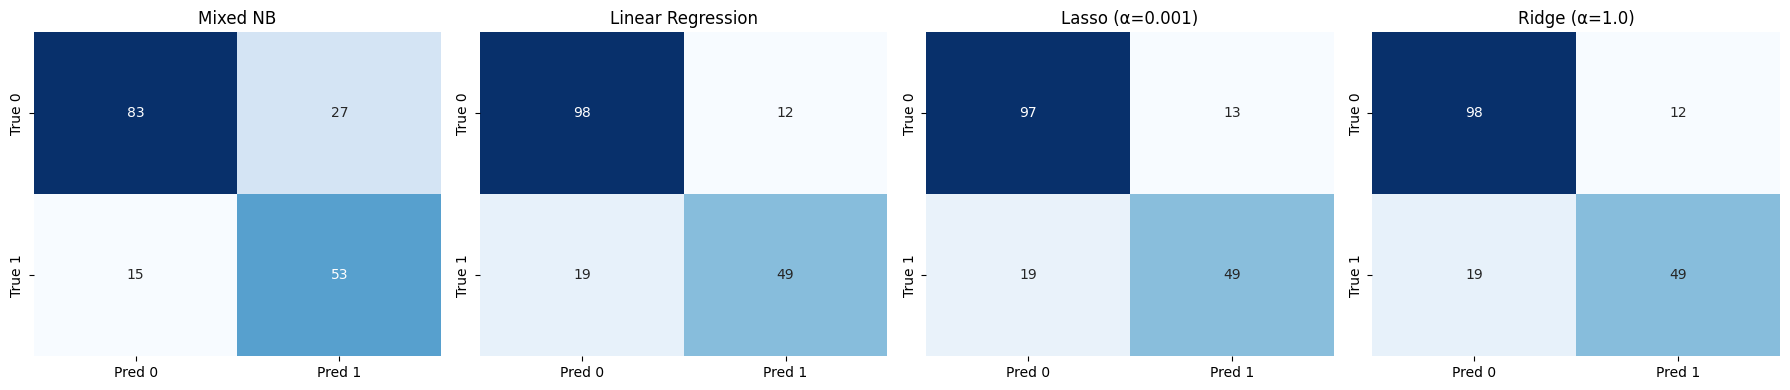

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, (y_true, y_pred)) in zip(axes, models.items()):
    stats = rows[name]
    cm = np.array([[stats['TN'], stats['FP']],
                   [stats['FN'], stats['TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'], ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [88]:
coefs = pd.Series(lr.coef_, index=['Pclass'] + lr_features)
((coefs.abs() / coefs.abs().sum()) * 100).sort_values(ascending=False).round(2)


Title_Mr           14.76
Title_Miss         14.24
Title_Rare         13.90
Sex                13.73
fam_size_large     13.45
Title_Mrs          12.96
Age                 6.33
has_cabin           2.74
Pclass              2.32
Embarked_Q          1.61
fam_size_medium     1.31
Fare                1.26
Embarked_S          0.76
Age_null            0.64
dtype: float64